<a href="https://colab.research.google.com/github/jannathasnain10thc-max/Phishing-Website-Detection/blob/main/phishing_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
url = input("Enter a website URL: ")

if "@" in url:
    print("⚠️ Suspicious URL")
elif "login" in url.lower() or "verify" in url.lower():
    print("⚠️ Suspicious URL")
else:
    print("✅ URL looks safe")

KeyboardInterrupt: Interrupted by user

In [ ]:
from urllib.parse import urlparse

def extract_features(url):
    features = {}

    # URL length
    features["url_length"] = len(url)

    # Number of dots
    features["num_dots"] = url.count(".")

    # Number of hyphens
    features["num_hyphens"] = url.count("-")

    # Number of slashes
    features["num_slashes"] = url.count("/")

    # Number of @ symbols
    features["has_at"] = 1 if "@" in url else 0

    # Check HTTPS
    features["uses_https"] = 1 if url.startswith("https://") else 0

    # Suspicious words
    suspicious_words = [
        "login",
        "verify",
        "account",
        "update",
        "secure",
        "password",
        "bank"
    ]

    features["has_suspicious_word"] = 0

    for word in suspicious_words:
        if word in url.lower():
            features["has_suspicious_word"] = 1
            break

    return features


# Ask user for a URL
url = input("Enter a website URL: ")

# Extract features
features = extract_features(url)

# Display features
print("\nURL Features:")
print("----------------------")

for feature, value in features.items():
    print(feature, ":", value)

In [10]:
import pandas as pd

df = pd.read_csv("dataset.csv")

print(df.head())

   index  having_IPhaving_IP_Address  URLURL_Length  Shortining_Service  \
0      1                          -1              1                   1   
1      2                           1              1                   1   
2      3                           1              0                   1   
3      4                           1              0                   1   
4      5                           1              0                  -1   

   having_At_Symbol  double_slash_redirecting  Prefix_Suffix  \
0                 1                        -1             -1   
1                 1                         1             -1   
2                 1                         1             -1   
3                 1                         1             -1   
4                 1                         1             -1   

   having_Sub_Domain  SSLfinal_State  Domain_registeration_length  ...  \
0                 -1              -1                           -1  ...   
1               

In [ ]:
print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

In [ ]:
print(df.tail())

In [ ]:
print(df.tail())

In [ ]:
print("Last column:", df.columns[-1])

print("\nValues in the last column:")
print(df.iloc[:, -1].value_counts())

In [11]:
X = df.drop("Result", axis=1)
y = df["Result"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11055, 31)
y shape: (11055,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (8844, 31)
Testing data: (2211, 31)


In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

NameError: name 'y_pred' is not defined

In [18]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print(y_pred[:20])

Predictions completed!
[-1 -1 -1  1  1  1  1 -1 -1  1  1  1  1  1  1 -1  1 -1  1 -1]


In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.9678878335594754
Model Accuracy (%): 96.78878335594754


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.98      0.95      0.96       956
           1       0.96      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



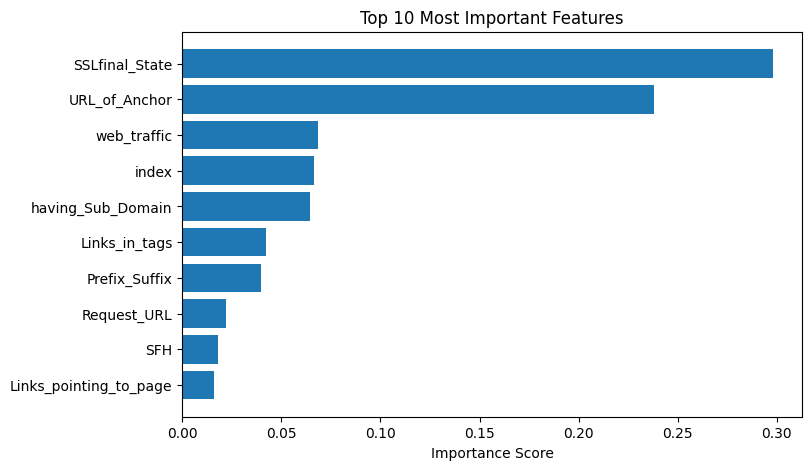

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance values from the trained model
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for easy plotting
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

# Plot the top 10 features
plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1])
plt.xlabel("Importance Score")
plt.title("Top 10 Most Important Features")
plt.show()

In [23]:
# Save test inputs, actual labels, and predicted labels to a single CSV
results_df = X_test.copy()
results_df['Actual_Result'] = y_test
results_df['Predicted_Result'] = y_pred

results_df.to_csv("model_predictions.csv", index=False)
print("Saved predictions to model_predictions.csv successfully!")

Saved predictions to model_predictions.csv successfully!


In [24]:
import joblib
from google.colab import files

# Save the model object
joblib.dump(model, 'random_forest_model.pkl')
print("Model saved as random_forest_model.pkl!")

# Download both output files to your local machine
files.download("model_predictions.csv")
files.download("random_forest_model.pkl")

Model saved as random_forest_model.pkl!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Confusion Matrix:
[[ 907   49]
 [  22 1233]]


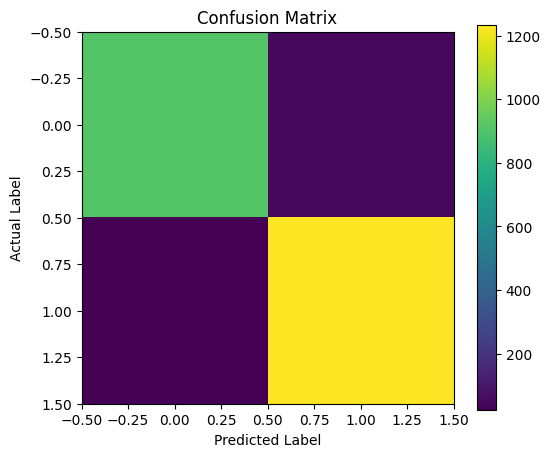

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()

plt.show()

# Phishing Website Detection using Random Forest

## 1. Import Libraries and Load Dataset

## 2. Data Preprocessing & Train-Test Split

## 3. Model Training (Random Forest)

## 4. Model Evaluation & Confusion Matrix

## 5. Feature Importance Analysis

## 6. Model Export & Predictions Download